# Subsystem Visualization Notebook

This notebook provides visualizations and progress tracking for the subsystems identified in the Legacy MUD codebase.
It focuses exclusively on visualization and exploration of data generated by the `subsystem_phase_2.ipynb` notebook.

## Setup and Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import os
import json
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from loguru import logger as log
from collections import defaultdict, Counter

# For interactive visualizations
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

PROJECT_ROOT = Path('../..').resolve()  # Adjust as needed to find the project root

import legacy_common.subsystem_utils as su
from legacy_common.doc_db import DocumentDB
import legacy_common.subsystem_identifier as si
import legacy_common.hierarchy_builder as hb
import legacy_common.subsystem_documenter as sd

## Load Generated Resources

First, we need to load the resources generated by the `subsystem_phase_2.ipynb` notebook. If you haven't run that notebook yet, do so before proceeding.

In [ ]:
# Define paths
GRAPH_PATH = su.DEFAULT_GRAPH_PATH
DB_PATH = su.DEFAULT_DB_PATH
INTEGRATED_CLUSTERS_PATH = su.INTERNAL_DIR / "integrated_clusters.json"
SUBSYSTEMS_PATH = su.INTERNAL_DIR / "subsystems.json"
HIERARCHY_PATH = su.INTERNAL_DIR / "system_hierarchy.json"

# Create visualizations directory if it doesn't exist
os.makedirs(su.VISUALIZATIONS_DIR, exist_ok=True)

# Load graph
log.info(f"Loading graph from {GRAPH_PATH}...")
graph = su.load_graph(GRAPH_PATH)
log.info(f"Loaded graph with {len(graph.nodes())} nodes and {len(graph.edges())} edges.")

# Load entity database
log.info(f"Loading entity database from {DB_PATH}...")
entity_db = su.load_entity_db(DB_PATH)
log.info(f"Loaded entity database with {len(entity_db.entities)} entries.")

# Load document database
log.info("Loading document database...")
from legacy_common.doc_db import docs_db
log.info(f"Loaded document database with {len(docs_db)} entries.")

# Load integrated clusters
print(f"Loading integrated clusters from {INTEGRATED_CLUSTERS_PATH}...")
integrated_clusters = su.load_clusters(INTEGRATED_CLUSTERS_PATH)
print(f"Loaded {len(integrated_clusters)} integrated clusters.")

# Load subsystems (if available)
try:
    print(f"Loading subsystems from {SUBSYSTEMS_PATH}...")
    subsystems = su.load_subsystems(SUBSYSTEMS_PATH)
    print(f"Loaded {len(subsystems)} subsystems.")
except FileNotFoundError:
    print(f"WARNING: Subsystems data not found at {SUBSYSTEMS_PATH}.")
    print("Please run the subsystem_phase_2.ipynb notebook first.")
    subsystems = {}

# Load hierarchy (if available)
try:
    print(f"Loading hierarchy from {HIERARCHY_PATH}...")
    with open(HIERARCHY_PATH, 'r') as f:
        hierarchy = json.load(f)
    print(f"Loaded hierarchy with {len(hierarchy.get('children', []))} top-level groups.")
    
    # Create subsystem graph for visualization
    subsystem_graph = nx.DiGraph()
    # Add nodes
    for s_id, subsystem in subsystems.items():
        subsystem_graph.add_node(s_id, name=subsystem.name, classification=subsystem.classification)
except FileNotFoundError:
    print(f"WARNING: Hierarchy data not found at {HIERARCHY_PATH}.")
    print("Please run the subsystem_phase_2.ipynb notebook first.")
    hierarchy = {}
    subsystem_graph = nx.DiGraph()

2025-06-25 17:07:44.845 | INFO     | __main__:<module>:12 - Loading graph from /Users/qte2333/repos/legacy/projects/doc_gen/internal/code_graph.gml...
2025-06-25 17:07:47.052 | INFO     | doxygen_graph:load_graph:606 - Graph loaded from /Users/qte2333/repos/legacy/projects/doc_gen/internal/code_graph.gml, nodes: 14507, edges: 60898
2025-06-25 17:07:47.052 | INFO     | doxygen_graph:load_graph:606 - Graph loaded from /Users/qte2333/repos/legacy/projects/doc_gen/internal/code_graph.gml, nodes: 14507, edges: 60898
2025-06-25 17:07:47.315 | INFO     | __main__:<module>:14 - Loaded graph with 4549 nodes and 45484 edges.
2025-06-25 17:07:47.315 | INFO     | __main__:<module>:17 - Loading entity database from /Users/qte2333/repos/legacy/projects/doc_gen/internal/code_graph.json...
2025-06-25 17:07:47.315 | INFO     | __main__:<module>:14 - Loaded graph with 4549 nodes and 45484 edges.
2025-06-25 17:07:47.315 | INFO     | __main__:<module>:17 - Loading entity database from /Users/qte2333/repos

Loading integrated clusters from /Users/qte2333/repos/legacy/projects/doc_gen/internal/integrated_clusters.json...
Loaded 47 integrated clusters.
Loading subsystems from /Users/qte2333/repos/legacy/projects/doc_gen/internal/subsystems.json...
Loaded 47 subsystems.
Loading hierarchy from /Users/qte2333/repos/legacy/projects/doc_gen/internal/system_hierarchy.json...
Loaded hierarchy with 4 top-level groups.


## Visualize Cluster Sizes

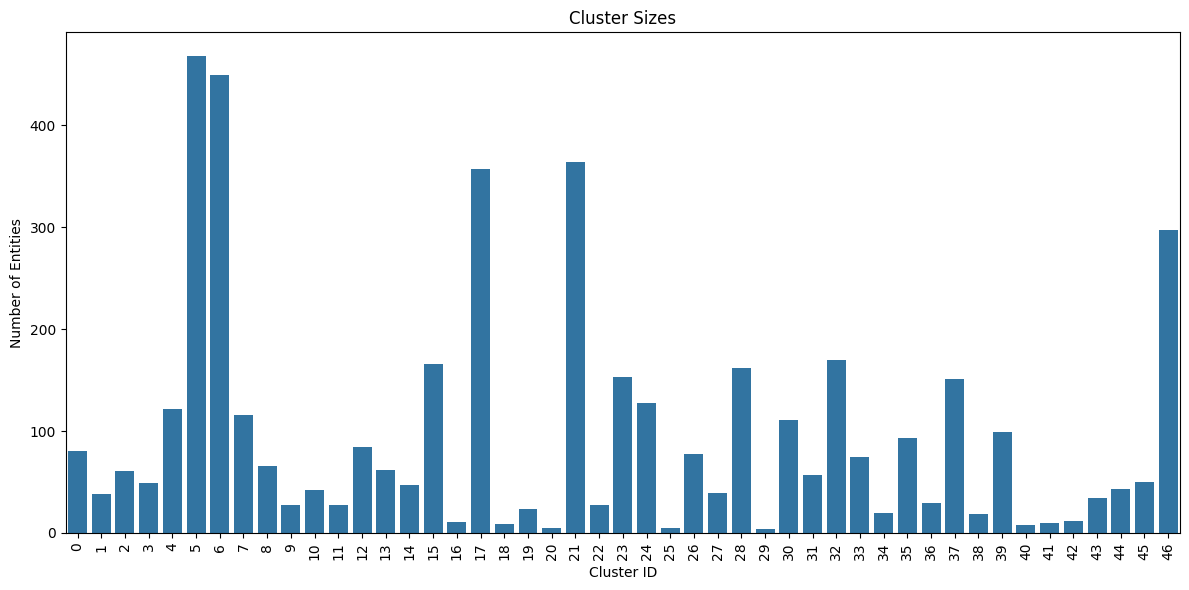

<Figure size 640x480 with 0 Axes>

In [4]:
# Extract cluster sizes
cluster_sizes = [len(cluster.nodes) for cluster in integrated_clusters.values()]
cluster_ids = [cluster.cluster_id for cluster in integrated_clusters.values()]

# Create cluster size dataframe
size_df = pd.DataFrame({
    'Cluster ID': cluster_ids,
    'Size': cluster_sizes
})
size_df = size_df.sort_values(by='Size', ascending=False)

# Create bar chart
plt.figure(figsize=(12, 6))
sns.barplot(data=size_df, x='Cluster ID', y='Size')
plt.title('Cluster Sizes')
plt.xlabel('Cluster ID')
plt.ylabel('Number of Entities')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Save plot
plt.savefig(su.VISUALIZATIONS_DIR / 'cluster_sizes.png')

## Visualize Cluster Network

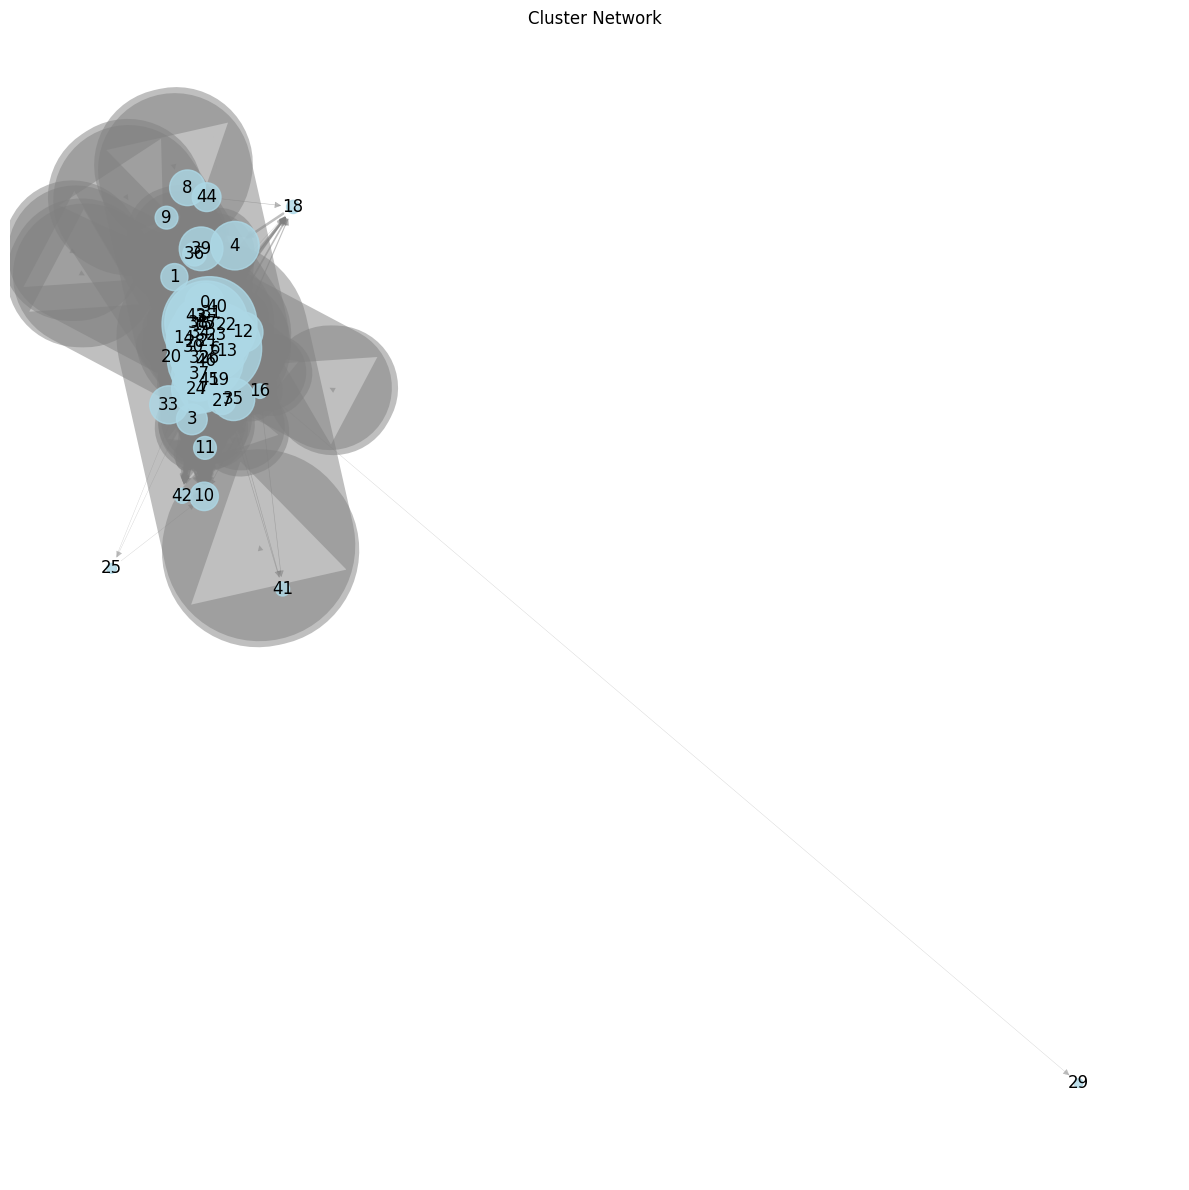

<Figure size 640x480 with 0 Axes>

In [5]:
def create_cluster_graph(graph, clusters):
    """Create a graph where nodes are clusters and edges represent connections."""
    # Create a mapping from entity to cluster
    entity_to_cluster = {}
    for cluster_id, cluster in clusters.items():
        for node in cluster.nodes:
            entity_to_cluster[node] = cluster_id
    
    # Create a new graph where nodes are clusters
    cluster_graph = nx.DiGraph()
    
    # Add nodes with size attribute
    for cluster_id, cluster in clusters.items():
        cluster_graph.add_node(cluster_id, size=len(cluster.nodes))

    # Add edges between clusters
    edge_counts = defaultdict(int)
    for u, v in graph.edges():
        if u in entity_to_cluster and v in entity_to_cluster:
            source_cluster = entity_to_cluster[u]
            target_cluster = entity_to_cluster[v]
            
            if source_cluster != target_cluster:
                edge_counts[(source_cluster, target_cluster)] += 1
    
    # Add edges to the cluster graph
    for (source, target), weight in edge_counts.items():
        cluster_graph.add_edge(source, target, weight=weight)
    
    return cluster_graph

# Create cluster graph
cluster_graph = create_cluster_graph(graph, integrated_clusters)

# Get node sizes and edge weights
node_sizes = [data['size'] * 10 for _, data in cluster_graph.nodes(data=True)]
edge_weights = [data['weight'] / 5 for _, _, data in cluster_graph.edges(data=True)]

# Create layout
pos = nx.spring_layout(cluster_graph, seed=42)

# Create figure
plt.figure(figsize=(12, 12))
nx.draw_networkx_nodes(cluster_graph, pos, node_size=node_sizes, alpha=0.8, node_color='lightblue')
nx.draw_networkx_edges(cluster_graph, pos, width=edge_weights, alpha=0.5, edge_color='gray', arrowsize=10)
nx.draw_networkx_labels(cluster_graph, pos)

plt.title('Cluster Network')
plt.axis('off')
plt.tight_layout()
plt.show()

# Save plot
plt.savefig(su.VISUALIZATIONS_DIR / 'cluster_network.png')

## Interactive Cluster Network

In [6]:
# Create interactive cluster network
def create_interactive_cluster_network(cluster_graph):
    # Create a Plotly figure
    fig = go.Figure()
    
    # Get positions using Fruchterman-Reingold layout
    pos = nx.spring_layout(cluster_graph, seed=42)
    
    # Get node sizes and prepare hover text
    node_x = []
    node_y = []
    node_text = []
    node_size = []
    
    for node, data in cluster_graph.nodes(data=True):
        x, y = pos[node]
        node_x.append(x)
        node_y.append(y)
        node_text.append(f"Cluster {node}<br>Size: {data['size']} entities")
        node_size.append(data['size'] * 2)  # Scale for visibility
    
    # Create nodes trace
    node_trace = go.Scatter(
        x=node_x, y=node_y,
        mode='markers',
        hoverinfo='text',
        text=node_text,
        marker=dict(
            showscale=True,
            colorscale='YlGnBu',
            size=node_size,
            colorbar=dict(
                thickness=15,
                title='Cluster Size',
                xanchor='left'
            ),
            color=node_size,
            line_width=2))
    
    # Create edges traces
    edge_x = []
    edge_y = []
    edge_text = []
    
    for u, v, data in cluster_graph.edges(data=True):
        x0, y0 = pos[u]
        x1, y1 = pos[v]
        edge_x.append(x0)
        edge_x.append(x1)
        edge_x.append(None)  # Separator
        edge_y.append(y0)
        edge_y.append(y1)
        edge_y.append(None)  # Separator
        edge_text.append(f"Connections: {data['weight']}")
    
    edge_trace = go.Scatter(
        x=edge_x, y=edge_y,
        line=dict(width=0.5, color='#888'),
        hoverinfo='none',
        mode='lines')
    
    # Create node labels
    node_labels = go.Scatter(
        x=node_x, y=node_y,
        mode='text',
        text=[str(node) for node in cluster_graph.nodes()],
        textposition='middle center',
        hoverinfo='none')
    
    # Add traces
    fig.add_trace(edge_trace)
    fig.add_trace(node_trace)
    fig.add_trace(node_labels)
    
    # Set layout
    fig.update_layout(
        title='Interactive Cluster Network',
#        titlefont_size=16,
        showlegend=False,
        hovermode='closest',
        margin=dict(b=20, l=5, r=5, t=40),
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False))
    
    return fig

# Create and display interactive cluster network
interactive_fig = create_interactive_cluster_network(cluster_graph)
interactive_fig.show()

# Save interactive visualization
interactive_fig.write_html(str(su.VISUALIZATIONS_DIR / 'interactive_cluster_network.html'))

## Check Generated Subsystems

This section explores the subsystems that were identified and categorized by the `subsystem_phase_2.ipynb` notebook.
If no subsystems are shown, make sure you've run that notebook first.

In [7]:
# Display subsystem summary
if not subsystems:
    print("No subsystems loaded. Please run subsystem_phase_2.ipynb first.")
else:
    # Group by classification
    by_classification = defaultdict(list)
    for subsystem in subsystems.values():
        by_classification[subsystem.classification].append(subsystem)
    
    # Display summary by classification
    print(f"Total subsystems: {len(subsystems)}")
    print("\nSubsystems by classification:")
    for classification, subs in sorted(by_classification.items()):
        print(f"- {classification}: {len(subs)} subsystems")
    
    # Display a sample of subsystems
    print("\nSample subsystems:")
    sample_size = min(5, len(subsystems))
    for i, (s_id, subsystem) in enumerate(list(subsystems.items())[:sample_size]):
        print(f"\n{i+1}. {subsystem.name} ({subsystem.classification})")
        print(f"   ID: {s_id}, Entities: {len(subsystem.nodes)}")
        if 'key_concepts' in subsystem.metadata and subsystem.metadata['key_concepts']:
            concepts = ', '.join(subsystem.metadata['key_concepts'])
            print(f"   Key concepts: {concepts}")

Total subsystems: 47

Subsystems by classification:
- Core: 24 subsystems
- Data: 13 subsystems
- Interface: 9 subsystems
- Support: 1 subsystems

Sample subsystems:

1. Obj Char (Core)
   ID: s6, Entities: 450
   Key concepts: obj, char, weight, extra, name

2. Array String (Core)
   ID: s7, Entities: 116
   Key concepts: array, string, print, parse, number

3. Vnum Prototype (Core)
   ID: s46, Entities: 297
   Key concepts: vnum, prototype, color, location, num

4. Spec Mprog (Core)
   ID: s17, Entities: 357
   Key concepts: spec, mprog, char, exit, act

5. Char Group (Core)
   ID: s21, Entities: 364
   Key concepts: char, group, level, table, poses


## Check Generated Subsystem Documentation

This section explores the documentation generated for each subsystem by the `subsystem_phase_2.ipynb` notebook.

In [8]:
# Check for generated documentation files
docs_dir = su.SUBSYSTEMS_DIR

if not docs_dir.exists():
    print(f"Subsystem documentation directory not found at {docs_dir}")
    print("Please run the subsystem_phase_2.ipynb notebook first.")
else:
    # List documentation files
    doc_files = list(docs_dir.glob("*.md"))
    
    if not doc_files:
        print(f"No documentation files found in {docs_dir}")
        print("Please run the subsystem_phase_2.ipynb notebook first.")
    else:
        print(f"Found {len(doc_files)} subsystem documentation files in {docs_dir}")
        
        # Display a sample of documentation files
        print("\nSample documentation files:")
        sample_size = min(3, len(doc_files))
        
        for i, file_path in enumerate(doc_files[:sample_size]):
            subsystem_name = file_path.stem.replace("_", " ").title()
            print(f"\n{i+1}. {subsystem_name}")
            
            # Read and display first few lines
            try:
                with open(file_path, 'r') as f:
                    content = f.read(500)  # Read first 500 characters
                
                # Print preview
                preview_lines = content.split('\n')[:8]  # First 8 lines
                print("\n".join(f"   {line}" for line in preview_lines))
                print("   ...")
            except Exception as e:
                print(f"   Error reading file: {e}")

Found 94 subsystem documentation files in /Users/qte2333/repos/legacy/.ai/docs/subsystems

Sample documentation files:

1. ~Flags ~Vnum ~String Subsystem
   
   # ~flags ~vnum ~string Subsystem
   
   **Classification**: Core
   **ID**: s7
   
   ## Overview
   
   ...

2. Race Name
   # Race Name
   
   **Classification**: Data
   **ID**: s39
   
   ## Overview
   
   This subsystem contains 99 entities and represents a cohesive functional unit within the Legacy MUD codebase.
   ...

3. Color Custom
   # Color Custom
   
   **Classification**: Data
   **ID**: s22
   
   ## Overview
   
   This subsystem contains 27 entities and represents a cohesive functional unit within the Legacy MUD codebase.
   ...


## Visualize Hierarchical Model

This section visualizes the hierarchical model created by the `subsystem_phase_2.ipynb` notebook.

In [9]:
# Check if hierarchy data is loaded
if not hierarchy:
    print("Hierarchy data not loaded. Please run subsystem_phase_2.ipynb first.")
else:
    # Display hierarchy structure
    print("Hierarchical Model Structure:\n")

    def print_hierarchy(node, level=0):
        indent = "  " * level
        name = node.get("name", "Unnamed")
        
        if "children" in node:
            print(f"{indent}+ {name}")
            for child in node.get("children", []):
                print_hierarchy(child, level + 1)
        else:
            size = node.get("size", "?")
            print(f"{indent}- {name} ({size} entities)")
    
    print_hierarchy(hierarchy)
    
    # Check for hierarchical view document
    HIERARCHY_DOC_PATH = su.DOCS_DIR / "hierarchical_view.md"
    if HIERARCHY_DOC_PATH.exists():
        print(f"\nHierarchical view document exists at: {HIERARCHY_DOC_PATH}")
    else:
        print(f"\nHierarchical view document not found at: {HIERARCHY_DOC_PATH}")
        print("Please run the subsystem_phase_2.ipynb notebook first.")
        
    # Build subsystem dependency graph if not already built
    if len(subsystem_graph.edges()) == 0 and len(subsystems) > 0:
        print("\nBuilding subsystem dependency graph for visualization...")
        
        # Build edges based on dependency relationships
        def identify_subsystem_dependencies(subsystem, all_subsystems):
            # Create a mapping from entity to subsystem
            entity_to_subsystem = {}
            for s_id, s in all_subsystems.items():
                for entity in s.nodes:
                    entity_to_subsystem[entity] = s_id
                
            # Identify subsystem dependencies
            dependencies = defaultdict(int)
            
            for entity in subsystem.nodes:
                # Check outgoing edges (dependencies)
                for target in graph.successors(entity):
                    if target in entity_to_subsystem and entity_to_subsystem[target] != subsystem.subsystem_id:
                        target_subsystem = entity_to_subsystem[target]
                        dependencies[target_subsystem] += 1
            
            return dependencies
        
        # Add edges to graph
        for s_id, subsystem in subsystems.items():
            deps = identify_subsystem_dependencies(subsystem, subsystems)
            for target_id, weight in deps.items():
                subsystem_graph.add_edge(s_id, target_id, weight=weight)
                
        print(f"Created subsystem graph with {len(subsystem_graph.nodes())} nodes and {len(subsystem_graph.edges())} edges.")

Hierarchical Model Structure:

+ Legacy MUD System
  + Core
    + Obj Char Group
      - Spec Mprog (357 entities)
      - Read Confirm (29 entities)
      - String Operator!= (42 entities)
      - Table Color (10 entities)
      - Vnum Name (5 entities)
      - Guild Level (62 entities)
      - Operator= Extra (47 entities)
      - Obj Char (450 entities)
      - From Obj (153 entities)
      - Weather Day (111 entities)
      - Color Scan (11 entities)
      - Char Group (364 entities)
      - Array String (116 entities)
      - Garbage List (27 entities)
    + Vnum Prototype Group
      - Flags Act (38 entities)
      - Operator Flags (75 entities)
      - Flags Name (162 entities)
      - Bit Core (66 entities)
      - Vnum Prototype (297 entities)
      - Char Level (468 entities)
      - String Prog (27 entities)
      - Level Squestmob (57 entities)
      - War Clan (170 entities)
      - Core variable (9 entities)
  + Support
    - Act Dispatcher (39 entities)
  + Data
    + Ha

## Create Interactive Hierarchy Visualization

Creating classification distribution visualizations...


/var/folders/8j/6xq5p2g15_l4v8nwldnc3f8c0000gn/T/ipykernel_37547/441324258.py:28: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/var/folders/8j/6xq5p2g15_l4v8nwldnc3f8c0000gn/T/ipykernel_37547/441324258.py:34: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




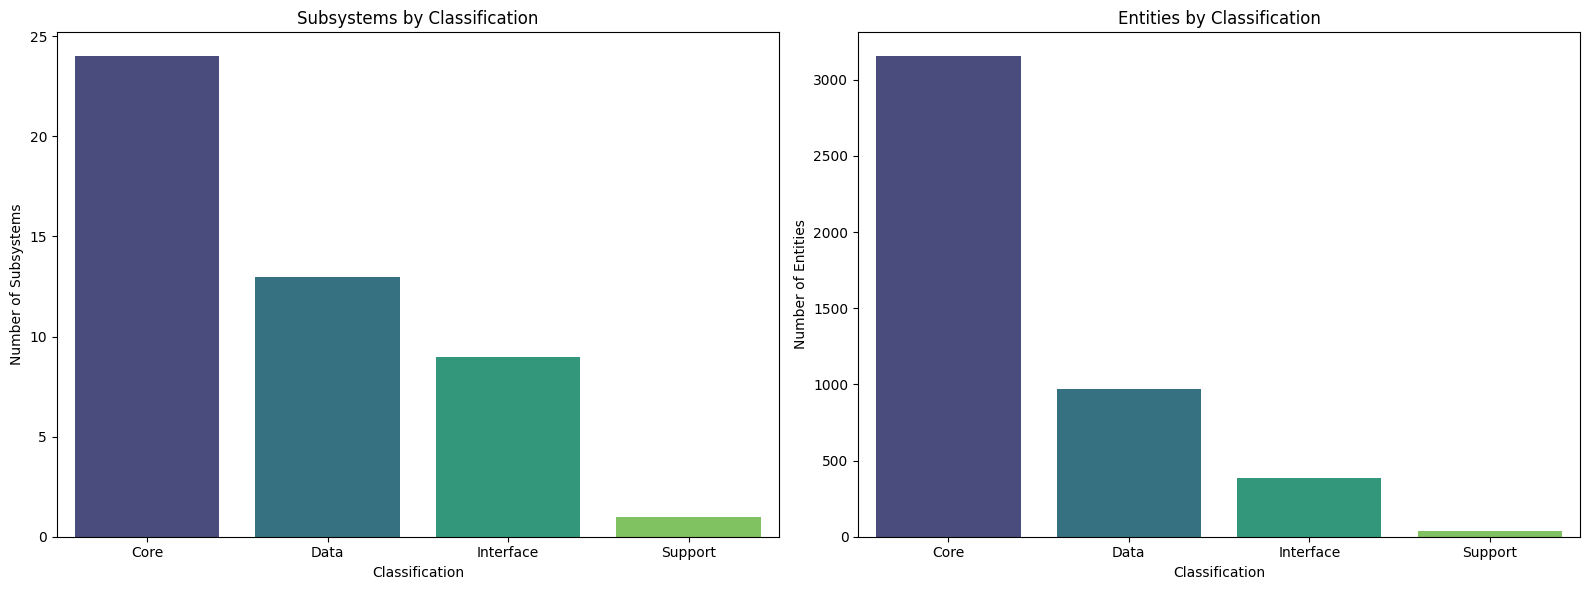

<Figure size 640x480 with 0 Axes>

In [10]:
# Create visualizations of subsystem classification distribution
print("Creating classification distribution visualizations...")

# Count subsystems and entities by classification
classification_counts = defaultdict(int)
entity_counts = defaultdict(int)

for s_id, subsystem in subsystems.items():
    classification = subsystem.classification
    classification_counts[classification] += 1
    entity_counts[classification] += len(subsystem.nodes)

# Create dataframes
subsystem_df = pd.DataFrame({
    'Classification': list(classification_counts.keys()),
    'Count': list(classification_counts.values())
}).sort_values('Count', ascending=False)

entity_df = pd.DataFrame({
    'Classification': list(entity_counts.keys()),
    'Count': list(entity_counts.values())
}).sort_values('Count', ascending=False)

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot subsystem counts
sns.barplot(data=subsystem_df, x='Classification', y='Count', ax=ax1, palette='viridis')
ax1.set_title('Subsystems by Classification')
ax1.set_ylabel('Number of Subsystems')
ax1.set_xlabel('Classification')

# Plot entity counts
sns.barplot(data=entity_df, x='Classification', y='Count', ax=ax2, palette='viridis')
ax2.set_title('Entities by Classification')
ax2.set_ylabel('Number of Entities')
ax2.set_xlabel('Classification')

# Adjust layout
plt.tight_layout()
plt.show()

# Save plot
plt.savefig(su.VISUALIZATIONS_DIR / 'classification_distribution.png')

# Create an interactive pie chart for distribution
fig = make_subplots(
    rows=1, cols=2, 
    specs=[[{'type':'domain'}, {'type':'domain'}]],
    subplot_titles=('Subsystems by Classification', 'Entities by Classification')
)

fig.add_trace(
    go.Pie(
        labels=subsystem_df['Classification'],
        values=subsystem_df['Count'],
        name='Subsystems'
    ),
    row=1, col=1
)

fig.add_trace(
    go.Pie(
        labels=entity_df['Classification'],
        values=entity_df['Count'],
        name='Entities'
    ),
    row=1, col=2
)

fig.update_layout(
    title_text='Distribution by Classification',
    height=500
)

fig.show()

# Save interactive visualization
fig.write_html(str(su.VISUALIZATIONS_DIR / 'classification_distribution.html'))

## Visualize Key Subsystem Relationships

In [11]:
# Create a visualization that focuses on key relationships between subsystems
def create_subsystem_relationship_visualization(subsystem_graph, subsystems):
    """
    Create a visualization focusing on key relationships between subsystems.
    
    Args:
        subsystem_graph: NetworkX graph of subsystem relationships
        subsystems: Dictionary of subsystem objects
    
    Returns:
        Plotly figure
    """
    # Create a filtered graph with only strong relationships
    filtered_graph = nx.DiGraph()
    
    # Add nodes
    for node, data in subsystem_graph.nodes(data=True):
        filtered_graph.add_node(node, **data)
    
    # Add edges with weight above threshold
    threshold = 5  # Adjust this as needed
    for u, v, data in subsystem_graph.edges(data=True):
        if data.get('weight', 0) >= threshold:
            filtered_graph.add_edge(u, v, **data)
    
    # Calculate centrality for node sizing
    centrality = nx.betweenness_centrality(filtered_graph)
    
    # Create a Plotly figure
    fig = go.Figure()
    
    # Get positions using Fruchterman-Reingold layout
    pos = nx.spring_layout(filtered_graph, seed=42)
    
    # Group nodes by classification
    nodes_by_class = defaultdict(list)
    for node, data in filtered_graph.nodes(data=True):
        classification = data.get('classification', 'Unknown')
        nodes_by_class[classification].append((node, data))
    
    # Color map for classifications
    color_map = {
        'Core': 'rgba(255, 0, 0, 0.8)',
        'Interface': 'rgba(0, 255, 0, 0.8)',
        'Support': 'rgba(0, 0, 255, 0.8)',
        'Data': 'rgba(255, 255, 0, 0.8)',
        'Extension': 'rgba(255, 0, 255, 0.8)',
        'Unknown': 'rgba(128, 128, 128, 0.8)'
    }
    
    # Add edges
    edge_x = []
    edge_y = []
    edge_text = []
    
    for u, v, data in filtered_graph.edges(data=True):
        x0, y0 = pos[u]
        x1, y1 = pos[v]
        edge_x.append(x0)
        edge_x.append(x1)
        edge_x.append(None)  # Separator
        edge_y.append(y0)
        edge_y.append(y1)
        edge_y.append(None)  # Separator
        
        # Source and target names
        source_name = subsystems[u].name if u in subsystems else u
        target_name = subsystems[v].name if v in subsystems else v
        weight = data.get('weight', 0)
        
        edge_text.append(f"{source_name} → {target_name}: {weight} connections")
    
    edge_trace = go.Scatter(
        x=edge_x, y=edge_y,
        line=dict(width=0.5, color='#888'),
        hoverinfo='text',
        text=edge_text,
        mode='lines')
    
    # Add nodes by classification
    for classification, nodes in nodes_by_class.items():
        node_x = []
        node_y = []
        node_text = []
        node_size = []
        
        for node, data in nodes:
            x, y = pos[node]
            node_x.append(x)
            node_y.append(y)
            
            # Get subsystem name and info
            s = subsystems[node] if node in subsystems else None
            name = s.name if s else node
            count = len(s.nodes) if s else 0
            
            node_text.append(f"{name}<br>Classification: {classification}<br>Entities: {count}")
            
            # Size based on centrality and entity count
            central_factor = centrality.get(node, 0.1) * 20
            count_factor = count / 10 if count else 1
            node_size.append(20 + central_factor + count_factor)
        
        node_trace = go.Scatter(
            x=node_x, y=node_y,
            mode='markers',
            hoverinfo='text',
            text=node_text,
            name=classification,
            marker=dict(
                color=color_map.get(classification, 'rgba(128, 128, 128, 0.8)'),
                size=node_size,
                line=dict(width=1, color='rgba(0, 0, 0, 0.8)')
            )
        )
        
        fig.add_trace(node_trace)
    
    # Add node labels
    for node in filtered_graph.nodes():
        x, y = pos[node]
        s = subsystems[node] if node in subsystems else None
        name = s.name if s else node
        
        # Extract meaningful part for label (avoid long names)
        label = name.split()[0] if ' ' in name else name
        
        label_trace = go.Scatter(
            x=[x], y=[y],
            mode='text',
            text=[label],
            textposition='middle center',
            hoverinfo='none',
            showlegend=False
        )
        
        fig.add_trace(label_trace)
    
    # Add edge trace
    fig.add_trace(edge_trace)
    
    # Set layout
    fig.update_layout(
        title='Key Subsystem Relationships',
        showlegend=True,
        hovermode='closest',
        margin=dict(b=20, l=5, r=5, t=40),
        legend=dict(
            title="Classification",
            yanchor="top",
            y=0.99,
            xanchor="left",
            x=0.01,
            bgcolor="rgba(255, 255, 255, 0.5)"
        ),
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False)
    )
    
    return fig

# Create and display key relationships visualization
key_relationships_fig = create_subsystem_relationship_visualization(subsystem_graph, subsystems)
key_relationships_fig.show()

# Save visualization
key_relationships_fig.write_html(str(su.VISUALIZATIONS_DIR / 'key_subsystem_relationships.html'))

In [12]:
# Create a treemap visualization of the hierarchy
def create_treemap(hierarchy):
    # Flatten hierarchy into a list for plotly
    def flatten_hierarchy(node, parent=""):
        results = []
        name = node.get("name", "")
        
        if "children" in node:
            # Non-leaf node
            results.append({
                "id": name,
                "parent": parent,
                "name": name,
                "value": None
            })
            
            for child in node["children"]:
                results.extend(flatten_hierarchy(child, name))
        else:
            # Leaf node
            results.append({
                "id": name,
                "parent": parent,
                "name": name,
                "value": node.get("size", 1)
            })
            
        return results
    
    flat_data = flatten_hierarchy(hierarchy)
    
    # Create dataframe
    df = pd.DataFrame(flat_data)
    
    # Create treemap
    fig = px.treemap(
        df,
        ids="id",
        names="name",
        parents="parent",
        values="value",
        title="Legacy MUD System Hierarchy"
    )
    
    # Update layout
    fig.update_layout(
        margin=dict(t=50, l=25, r=25, b=25)
    )
    
    return fig

# Create and display treemap
treemap_fig = create_treemap(hierarchy)
treemap_fig.show()

# Save treemap
treemap_fig.write_html(str(su.VISUALIZATIONS_DIR / 'system_hierarchy_treemap.html'))

## Visualize Classification Distribution

## Summary of Visualization Notebook

This notebook provides visualizations for Phase 2 (Hierarchical Concept Modeling) outputs of the high-level component discovery plan. 

### Data Requirements
This notebook relies on data generated from the `subsystem_phase_2.ipynb` notebook. Ensure you've run that notebook first to generate:

1. **Subsystem data**:
   - Subsystem definitions: `projects/doc_gen/internal/subsystems.json`

2. **Hierarchical model**:
   - System hierarchy: `projects/doc_gen/internal/system_hierarchy.json`

3. **Documentation**:
   - Subsystem catalog: `.ai/docs/subsystems_catalog.md`
   - Hierarchical view document: `.ai/docs/hierarchical_view.md`
   - Individual subsystem docs: `.ai/docs/subsystems/*.md`

### Visualizations Provided
1. Cluster size bar chart
2. Cluster network visualization
3. Interactive cluster network
4. System hierarchy treemap
5. Key subsystem relationships visualization
6. Classification distribution charts

### Workflow
1. Run `subsystem_phase_2.ipynb` to generate the data
2. Run this notebook to visualize and explore the results
3. Use these visualizations to understand the system structure

## Next Steps

After reviewing the visualizations, proceed to:

1. Phase 3: Cross-Cutting Concern Analysis
   - Utility Node Analysis
   - Aspect Mining
   - Service Extraction

2. Phase 4: Domain Concept Extraction
   - Vocabulary Mining
   - Conceptual Model
   - Domain-Driven Design Analysis

3. Phase 5: Quality Analysis & Visualization
   - Metrics Collection
   - Technical Debt Mapping
   - Interactive Visualizations

## Using the Phase 2 Modules

This notebook relies on the following modules:

1. **`subsystem_identifier.py`**: 
   - Responsible for analyzing clusters and identifying coherent subsystems
   - Implements subsystem naming, classification, and boundary detection
   - Data generation handled in `subsystem_phase_2.ipynb`

2. **`hierarchy_builder.py`**: 
   - Implements hierarchical organization of subsystems
   - Creates dependency graphs between subsystems
   - Data generation handled in `subsystem_phase_2.ipynb`

3. **`subsystem_documenter.py`**:
   - Generates comprehensive documentation for each subsystem
   - Identifies interfaces and dependencies between subsystems
   - Data generation handled in `subsystem_phase_2.ipynb`

This separation of concerns allows you to:
1. Generate all data once with the Phase 2 notebook
2. Explore and visualize that data multiple times with this notebook
3. Modify visualizations without re-running the potentially time-consuming data generation